# SageServe : Forecast Preparation

## Purpose

This notebook prepares the synthetic SageServe workload for the
forecast-aware scaling experiment.

The goal is to:

1. Load `random_trace.csv`.
2. Construct the workload signal used for forecasting.
3. Aggregate prompt-token demand over time.
4. Examine the workload separately by model and region.
5. Validate the resulting time series.
6. Prepare the data that will later be used to generate ARIMA forecasts.

The forecast-aware SageServe arbiter uses predicted prompt-token demand,
so the forecasting signal is based on `prompt_size` aggregated over time.

This notebook does not yet run the SageServe simulator.

## 1. Load the SageServe trace

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

trace_path = Path("../traces/random_trace.csv")

if not trace_path.exists():
    raise FileNotFoundError(f"Trace not found: {trace_path.resolve()}")

df = pd.read_csv(trace_path)

print("Trace:", trace_path.resolve())
print("Shape:", df.shape)

df.head()

Trace: /home/sreenath-karthick/repos/Sage-Serve/SageServe-original/traces/random_trace.csv
Shape: (63674, 15)


,request_id,batch_id,client_tenant,request_type,scenario,sla,utility,regions,model_type,workload_type,application_id,arrival_timestamp,batch_size,prompt_size,token_size
0,0,0,1,2,EnterpriseSydney,86400,1,210,D,dev,0,0,128,630,25
1,0,0,1,2,EnterpriseSydney,86400,1,210,D,dev,0,0,128,799,520
2,0,0,1,2,EnterpriseSydney,86400,1,210,D,dev,0,0,128,135,440
3,0,0,1,2,EnterpriseSydney,86400,1,210,D,dev,0,0,128,998,621
4,0,0,1,2,EnterpriseSydney,86400,1,210,D,dev,0,0,128,318,359


## 2. Validate the trace

Check the columns required for forecasting and verify that the timestamps
and prompt sizes contain valid values.

In [2]:
required_columns = [
    "arrival_timestamp",
    "model_type",
    "regions",
    "prompt_size",
]

missing = [c for c in required_columns if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Required columns present.")

print("\nMissing values:")
print(df[required_columns].isnull().sum())

print("\nPrompt-size statistics:")
print(df["prompt_size"].describe())

print("\nModel types:")
print(sorted(df["model_type"].unique()))

print("\nRegion codes:")
print(sorted(df["regions"].astype(str).unique()))

Required columns present.

Missing values:
arrival_timestamp    0
model_type           0
regions              0
prompt_size          0
dtype: int64

Prompt-size statistics:
count    63674.000000
mean       513.217247
std        295.858634
min          1.000000
25%        257.000000
50%        514.000000
75%        771.000000
max       1024.000000
Name: prompt_size, dtype: float64

Model types:
['A', 'B', 'C', 'D']

Region codes:
['102', '12', '120', '201', '21', '210']


## 3. Aggregate prompt-token demand by minute

The forecast signal is the total prompt-token demand observed during
each one-minute interval.

For timestamp `t`, all requests arriving during that minute are
aggregated using:

    workload_t = sum(prompt_size)

This gives a time series suitable for forecasting.

In [3]:
df["minute"] = df["arrival_timestamp"] // 60

prompt_tokens_per_minute = (
    df.groupby("minute")["prompt_size"]
      .sum()
      .sort_index()
)

prompt_tokens_per_minute.head()

minute
0    359709
1    611799
2    354383
3    408688
4    164139
Name: prompt_size, dtype: int64

In [4]:
print("Number of minutes:", len(prompt_tokens_per_minute))
print("\nStatistics:")
print(prompt_tokens_per_minute.describe())

Number of minutes: 84

Statistics:
count        84.000000
mean     389030.892857
std      145235.107367
min       97758.000000
25%      291629.750000
50%      360878.500000
75%      481383.250000
max      759880.000000
Name: prompt_size, dtype: float64


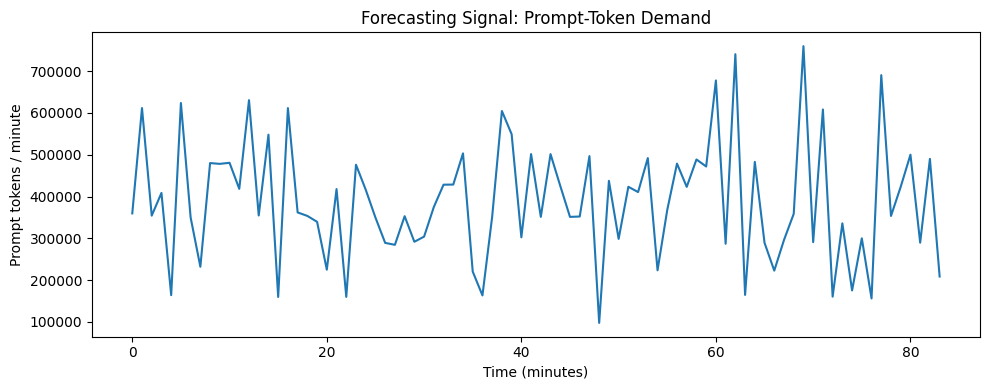

In [6]:
plt.figure(figsize=(10, 4))

plt.plot(
    prompt_tokens_per_minute.index,
    prompt_tokens_per_minute.values
)

plt.xlabel("Time (minutes)")
plt.ylabel("Prompt tokens / minute")
plt.title("Forecasting Signal: Prompt-Token Demand")
plt.tight_layout()
plt.show()

In [7]:
expected_minutes = range(
    prompt_tokens_per_minute.index.min(),
    prompt_tokens_per_minute.index.max() + 1
)

missing_minutes = sorted(
    set(expected_minutes) - set(prompt_tokens_per_minute.index)
)

print("Missing minutes:", missing_minutes)

Missing minutes: []


In [8]:
print("Final time-series length:", len(prompt_tokens_per_minute))

Final time-series length: 84


## 4. Prompt-token demand by model

The SageServe workload contains four models:

- A
- B
- C
- D

We construct a separate time series for each model.

In [9]:
model_load = (
    df.groupby(["minute", "model_type"])["prompt_size"]
      .sum()
      .unstack(fill_value=0)
      .sort_index()
)

model_load.head()

model_type,A,B,C,D
minute,,,,
0,75054,6732,133645,144278
1,207908,69708,145223,188960
2,261820,8957,6325,77281
3,193887,8514,134153,72134
4,6412,70343,76822,10562


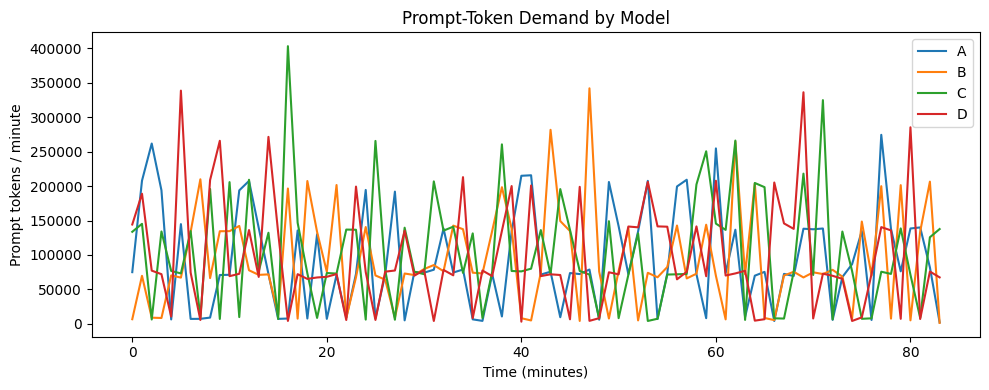

In [10]:
plt.figure(figsize=(10, 4))

for model in model_load.columns:
    plt.plot(
        model_load.index,
        model_load[model],
        label=model
    )

plt.xlabel("Time (minutes)")
plt.ylabel("Prompt tokens / minute")
plt.title("Prompt-Token Demand by Model")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Region encoding

The trace contains the following region values:

```text
12
21
102
120
201
210
```

These values appear to encode regional routing information.

Before generating region-specific forecast files, the meaning of this
encoding must be verified from SageServe's routing/trace-processing code.

No region-specific forecast is generated in this notebook until that
mapping is confirmed.



In [11]:
region_codes = (
    df["regions"]
    .astype(str)
    .value_counts()
    .sort_index()
)

region_codes

regions
102    11507
12      8853
120    10755
201    11463
21     10098
210    10998
Name: count, dtype: int64

Create model × region workload table

We can prepare the raw grouped table now, without deciding how the route encoding maps to forecast regions.

In [12]:
model_region_load = (
    df.groupby(
        ["minute", "model_type", "regions"]
    )["prompt_size"]
    .sum()
    .reset_index()
)

model_region_load.head(20)

,minute,model_type,regions,prompt_size
0,0,A,12,1007
1,0,A,102,2503
2,0,A,120,2005
3,0,A,201,2473
4,0,A,210,67066
5,0,B,12,2065
6,0,B,102,939
7,0,B,120,1458
8,0,B,201,528
9,0,B,210,1742


In [13]:
print(
    "Model-region combinations:",
    model_region_load[["model_type", "regions"]]
    .drop_duplicates()
    .shape[0]
)


Model-region combinations: 24


In [14]:
model_region_load[
    ["model_type", "regions"]
].drop_duplicates().sort_values(
    ["model_type", "regions"]
)


,model_type,regions
0,A,12
23,A,21
1,A,102
2,A,120
3,A,201
4,A,210
5,B,12
29,B,21
6,B,102
7,B,120


In [15]:
example = model_region_load[
    (model_region_load["model_type"] == "A") &
    (model_region_load["regions"].astype(str) == "210")
].copy()

example.head(20)

,minute,model_type,regions,prompt_size
4,0,A,210,67066
27,1,A,210,983
50,2,A,210,61037
70,3,A,210,73356
92,4,A,210,520
139,6,A,210,1480
163,7,A,210,627
185,8,A,210,2800
207,9,A,210,902
231,10,A,210,1761


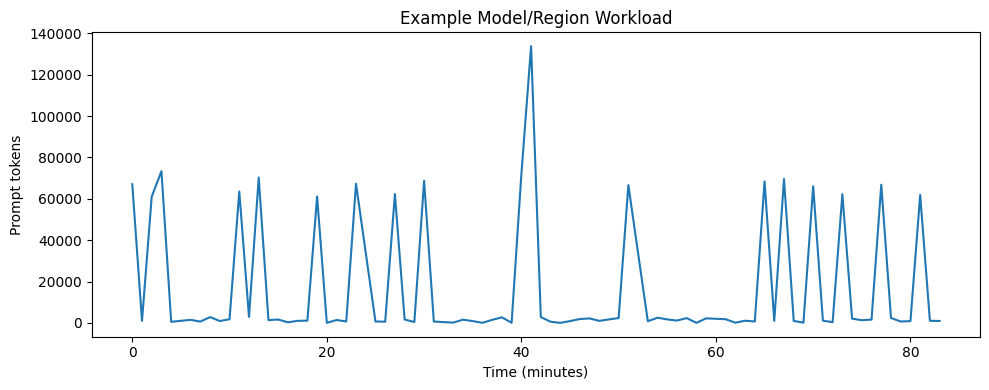

In [16]:
plt.figure(figsize=(10, 4))

plt.plot(
    example["minute"],
    example["prompt_size"]
)

plt.xlabel("Time (minutes)")
plt.ylabel("Prompt tokens")
plt.title("Example Model/Region Workload")
plt.tight_layout()
plt.show()

## 6. ARIMA preparation

The next stage is to generate SageServe-compatible ARIMA forecast files.

Before doing this, the following must be confirmed from the SageServe
implementation:

1. How `regions` values map to the three SageServe regions.
2. Which workload categories are forecast separately.
3. The exact expected forecast filename.
4. The exact meaning of the `Time` and `Predicted` columns.
5. The forecasting horizon used by the ARIMA-aware arbiter.

Once these are verified, an ARIMA model can be fitted to each required
model-region workload time series and the predictions can be written to
`traces/forecasts/`.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

In [21]:
# ---------------------------------------------------------
# ARIMA configuration
# ---------------------------------------------------------

ARIMA_ORDER = (1, 1, 1)

# SageServe makes a forecast for the next one-hour window.
FORECAST_HORIZON_MINUTES = 60

# We use one-minute workload buckets.
BUCKET_SECONDS = 60

print("ARIMA order:", ARIMA_ORDER)
print("Forecast horizon:", FORECAST_HORIZON_MINUTES, "minutes")

ARIMA order: (1, 1, 1)
Forecast horizon: 60 minutes


In [22]:
# Convert the model-level workload from tokens/minute to tokens/second.

model_tps = model_load / BUCKET_SECONDS

model_tps.head()

model_type,A,B,C,D
minute,,,,
0,1250.900000,112.200000,2227.416667,2404.633333
1,3465.133333,1161.800000,2420.383333,3149.333333
2,4363.666667,149.283333,105.416667,1288.016667
3,3231.450000,141.900000,2235.883333,1202.233333
4,106.866667,1172.383333,1280.366667,176.033333


In [23]:
full_minutes = pd.RangeIndex(
    start=model_tps.index.min(),
    stop=model_tps.index.max() + 1,
    step=1,
    name="minute",
)

model_tps = (
    model_tps
    .reindex(full_minutes, fill_value=0)
)

print("Time-series length:", len(model_tps))
print("Missing minutes:", model_tps.isna().sum().sum())

Time-series length: 84
Missing minutes: 0


In [24]:
def generate_arima_forecast(
    series: pd.Series,
    horizon: int = 60,
    order: tuple[int, int, int] = (1, 1, 1),
) -> tuple[pd.DataFrame, object]:
    """
    Fit an ARIMA model to a historical TPS series and
    forecast the next `horizon` time intervals.
    """

    series = series.astype(float).copy()

    if len(series) < 10:
        raise ValueError(
            f"Not enough observations for ARIMA: {len(series)}"
        )

    model = ARIMA(
        series,
        order=order,
    )

    fitted = model.fit()

    predictions = fitted.forecast(steps=horizon)

    start_minute = int(series.index.max()) + 1

    future_minutes = np.arange(
        start_minute,
        start_minute + horizon,
    )

    forecast_df = pd.DataFrame({
        "Time": future_minutes,
        "Predicted": np.asarray(predictions, dtype=float),
    })

    # TPS cannot be negative.
    forecast_df["Predicted"] = forecast_df["Predicted"].clip(lower=0)

    return forecast_df, fitted

In [29]:
model = "A"

series = model_tps[model]

forecast_A, fitted_A = generate_arima_forecast(
    series,
    horizon=FORECAST_HORIZON_MINUTES,
    order=ARIMA_ORDER,
)

forecast_A.head(10)

,Time,Predicted
0,84,1392.847253
1,85,1523.290868
2,86,1535.821051
3,87,1537.024679
4,88,1537.140297
5,89,1537.151403
6,90,1537.152470
7,91,1537.152572
8,92,1537.152582
9,93,1537.152583


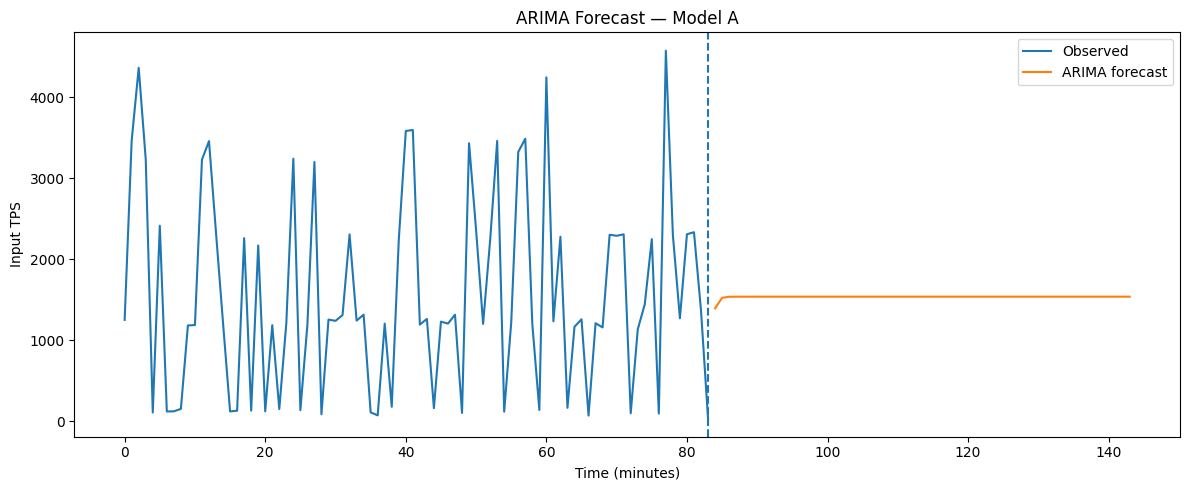

In [30]:
plt.figure(figsize=(12, 5))

plt.plot(
    series.index,
    series.values,
    label="Observed",
)

plt.plot(
    forecast_A["Time"],
    forecast_A["Predicted"],
    label="ARIMA forecast",
)

plt.axvline(
    series.index.max(),
    linestyle="--",
)

plt.xlabel("Time (minutes)")
plt.ylabel("Input TPS")
plt.title(f"ARIMA Forecast — Model {model}")

plt.legend()
plt.tight_layout()
plt.show()

In [31]:
all_forecasts = []
fitted_models = {}

for model in sorted(model_tps.columns):

    print(f"Generating forecast for Model {model}...")

    series = model_tps[model]

    forecast_df, fitted = generate_arima_forecast(
        series,
        horizon=FORECAST_HORIZON_MINUTES,
        order=ARIMA_ORDER,
    )

    forecast_df["Model"] = model

    all_forecasts.append(forecast_df)
    fitted_models[model] = fitted

arima_forecasts = pd.concat(
    all_forecasts,
    ignore_index=True,
)

arima_forecasts = arima_forecasts[
    ["Model", "Time", "Predicted"]
]

arima_forecasts.head(20)

Generating forecast for Model A...
Generating forecast for Model B...
Generating forecast for Model C...
Generating forecast for Model D...


,Model,Time,Predicted
0,A,84,1392.847253
1,A,85,1523.290868
2,A,86,1535.821051
3,A,87,1537.024679
4,A,88,1537.140297
5,A,89,1537.151403
6,A,90,1537.152470
7,A,91,1537.152572
8,A,92,1537.152582
9,A,93,1537.152583


In [32]:
forecast_peaks = (
    arima_forecasts
    .groupby("Model")["Predicted"]
    .max()
    .reset_index()
    .rename(columns={
        "Predicted": "PeakPredictedTPS"
    })
)

forecast_peaks

,Model,PeakPredictedTPS
0,A,1537.152583
1,B,1809.161986
2,C,1750.536739
3,D,1688.033317


In [33]:
forecasts_dir = Path("../traces/forecasts")
forecasts_dir.mkdir(parents=True, exist_ok=True)

master_forecast_path = (
    forecasts_dir / "arima_forecasts.csv"
)

arima_forecasts.to_csv(
    master_forecast_path,
    index=False,
)

peak_forecast_path = (
    forecasts_dir / "arima_forecast_peaks.csv"
)

forecast_peaks.to_csv(
    peak_forecast_path,
    index=False,
)

print("Saved:")
print(master_forecast_path.resolve())
print(peak_forecast_path.resolve())

Saved:
/home/sreenath-karthick/repos/Sage-Serve/SageServe-original/traces/forecasts/arima_forecasts.csv
/home/sreenath-karthick/repos/Sage-Serve/SageServe-original/traces/forecasts/arima_forecast_peaks.csv


In [34]:
for model in sorted(arima_forecasts["Model"].unique()):

    model_forecast = arima_forecasts[
        arima_forecasts["Model"] == model
    ].copy()

    output_path = (
        forecasts_dir / f"forecast_model_{model}.csv"
    )

    model_forecast[
        ["Time", "Predicted"]
    ].to_csv(
        output_path,
        index=False,
    )

    print("Saved:", output_path)

Saved: ../traces/forecasts/forecast_model_A.csv
Saved: ../traces/forecasts/forecast_model_B.csv
Saved: ../traces/forecasts/forecast_model_C.csv
Saved: ../traces/forecasts/forecast_model_D.csv
